This project is used to predict if a customer is going to leave(Churn) or stay

### The first thing we are going to do is merging the files based on Customer ID .

In [2]:
import pandas as pd

In [3]:
demo = pd.read_excel("Demographics.xlsx")
Location = pd.read_excel("Location.xlsx")
pop = pd.read_excel("Population.xlsx")
service = pd.read_excel("Services.xlsx")
status = pd.read_excel("Status.xlsx")

In [4]:
demo   = demo.drop(columns="Count")
Location = Location.drop(columns="Count")
service = service.drop(columns="Count")
status  = status.drop(columns="Count")


In [5]:
demo.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents
0,8779-QRDMV,Male,78,No,Yes,No,No,0
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1


In [7]:
Location.head()

,Location ID,Customer ID,Country,State,City,Zip Code,Lat Long,Latitude,Longitude
0,OXCZEW7397,8779-QRDMV,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582
1,FCCECI8494,7495-OOKFY,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237
2,HEHUQY7254,1658-BYGOY,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715
3,WIUHRF2613,4598-XLKNJ,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639
4,CFEZBF4415,4846-WHAFZ,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188


In [8]:
pop.head()

,ID,Zip Code,Population
0,1,90001,54492
1,2,90002,44586
2,3,90003,58198
3,4,90004,67852
4,5,90005,43019


In [10]:
df = (
    demo
    .merge(Location, on="Customer ID", how="left")
    .merge(pop, on="Zip Code", how="left")
    .merge(service, on="Customer ID", how="left")
    .merge(status, on="Customer ID", how="left")
)

In [11]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Location ID,Country,...,Total Revenue,Status ID,Quarter_y,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,OXCZEW7397,United States,...,59.65,SWSORB1252,Q3,3,Churned,Yes,1,91,5433,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,FCCECI8494,United States,...,1024.10,SNAEQA8572,Q3,3,Churned,Yes,1,69,5302,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,HEHUQY7254,United States,...,1910.88,LMBQNN3714,Q3,2,Churned,Yes,1,81,3179,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,WIUHRF2613,United States,...,2995.07,VRZYZI9978,Q3,2,Churned,Yes,1,88,5337,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,CFEZBF4415,United States,...,3102.36,FDNAKX1688,Q3,2,Churned,Yes,1,67,2793,Extra data charges


In [5]:
df.to_excel("merged_telco_churn.xlsx", index=False, sheet_name="Telco_Churn")

### In these columns , 0 means no and 1 means yes : 

- Under 30 
- Senior citizen
- married
- dependents
- Referred a Friend
- phone service
- Multiple Lines
- Internet Service
- Online Security
- Online Backup
- Device Protection Plan
- Premium Tech Support
- Streaming TV
- Streaming Movies
- Streaming Music
- Unlimited Data
- Paperless Billing



- we filled Null offers with no offers

I cleared the ID columns because they do not give us useful information

one of the churn labels , churn values .

the country(It was only USA)

the state(Only California)

the city(because of overfitting)

Latitude/Longitude/Lat Long

churn score(because it's like a model copying another model for predicting)

senior citizen and under 30 when we have age

zip code

- For gender i set male for 0 and female for 1 
- contract type :  Month-to-Month(0) , One year(1) , Two year(2)

### Now that the data is cleaned , we can train our model with different algorithms : 

### 1- logistic regression : 

In [12]:
data = pd.read_excel("cleaned.xlsx")

In [13]:
data.head()

,Gender,Age,Married,Dependents,Number of Dependents,Population,Referred a Friend,Number of Referrals,Tenure in Months,Offer,...,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Label
0,0.0,78.0,0.0,0.0,0.0,68701.0,0.0,0.0,1.0,No offer,...,1.0,Bank Withdrawal,39.65,39.65,0.00,20.0,0.00,59.65,3.0,1.0
1,1.0,74.0,1.0,1.0,1.0,55668.0,1.0,1.0,8.0,Offer E,...,1.0,Credit Card,80.65,633.30,0.00,0.0,390.80,1024.10,3.0,1.0
2,0.0,71.0,0.0,1.0,3.0,47534.0,0.0,0.0,18.0,Offer D,...,1.0,Bank Withdrawal,95.45,1752.55,45.61,0.0,203.94,1910.88,2.0,1.0
3,1.0,78.0,1.0,1.0,1.0,27778.0,1.0,1.0,25.0,Offer C,...,1.0,Bank Withdrawal,98.50,2514.50,13.43,0.0,494.00,2995.07,2.0,1.0
4,1.0,80.0,1.0,1.0,1.0,26265.0,1.0,1.0,37.0,Offer C,...,1.0,Bank Withdrawal,76.50,2868.15,0.00,0.0,234.21,3102.36,2.0,1.0


In [14]:
data.describe()

,Gender,Age,Married,Dependents,Number of Dependents,Population,Referred a Friend,Number of Referrals,Tenure in Months,Phone Service,...,Contract,Paperless Billing,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Label
count,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,...,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000
mean,0.495170,46.497301,0.483097,0.231108,0.468892,22133.273011,0.457528,1.952415,32.396023,0.903125,...,0.755114,0.592045,64.751761,2281.009409,1.963018,6.863636,749.369311,3035.279338,3.245597,0.265057
std,0.500012,16.742978,0.499750,0.421571,0.962958,21153.235679,0.498228,3.001658,24.542022,0.295808,...,0.848506,0.491490,30.092021,2266.438247,7.904194,25.109928,846.738270,2865.427733,1.201314,0.441395
min,0.000000,19.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,0.000000
25%,0.000000,32.000000,0.000000,0.000000,0.000000,2344.000000,0.000000,0.000000,9.000000,1.000000,...,0.000000,0.000000,35.500000,400.900000,0.000000,0.000000,70.567500,605.787500,3.000000,0.000000
50%,0.000000,46.000000,0.000000,0.000000,0.000000,17494.000000,0.000000,0.000000,29.000000,1.000000,...,0.000000,1.000000,70.350000,1394.800000,0.000000,0.000000,401.960000,2108.645000,3.000000,0.000000
75%,1.000000,60.000000,1.000000,0.000000,0.000000,36125.000000,1.000000,3.000000,55.000000,1.000000,...,2.000000,1.000000,89.850000,3789.800000,0.000000,0.000000,1191.607500,4803.122500,4.000000,1.000000
max,1.000000,80.000000,1.000000,1.000000,9.000000,105285.000000,1.000000,11.000000,72.000000,1.000000,...,2.000000,1.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,1.000000


 ### Now to find the correlation : 

In [32]:
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 

In [10]:
numeric_cols = [
    'Age', 'Number of Dependents', 'Population', 'Number of Referrals',
    'Tenure in Months', 'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges',
    'Total Refunds', 'Total Extra Data Charges',
    'Total Long Distance Charges', 'Total Revenue',
    'Satisfaction Score', 'Churn Label'
]

---

In [19]:
print(data[numeric_cols].dtypes)

Age                                  float64
Number of Dependents                 float64
Population                           float64
Number of Referrals                  float64
Tenure in Months                     float64
Avg Monthly Long Distance Charges    float64
Avg Monthly GB Download              float64
Monthly Charge                       float64
Total Charges                        float64
Total Refunds                        float64
Total Extra Data Charges             float64
Total Long Distance Charges          float64
Total Revenue                        float64
Satisfaction Score                   float64
Churn Label                          float64
dtype: object


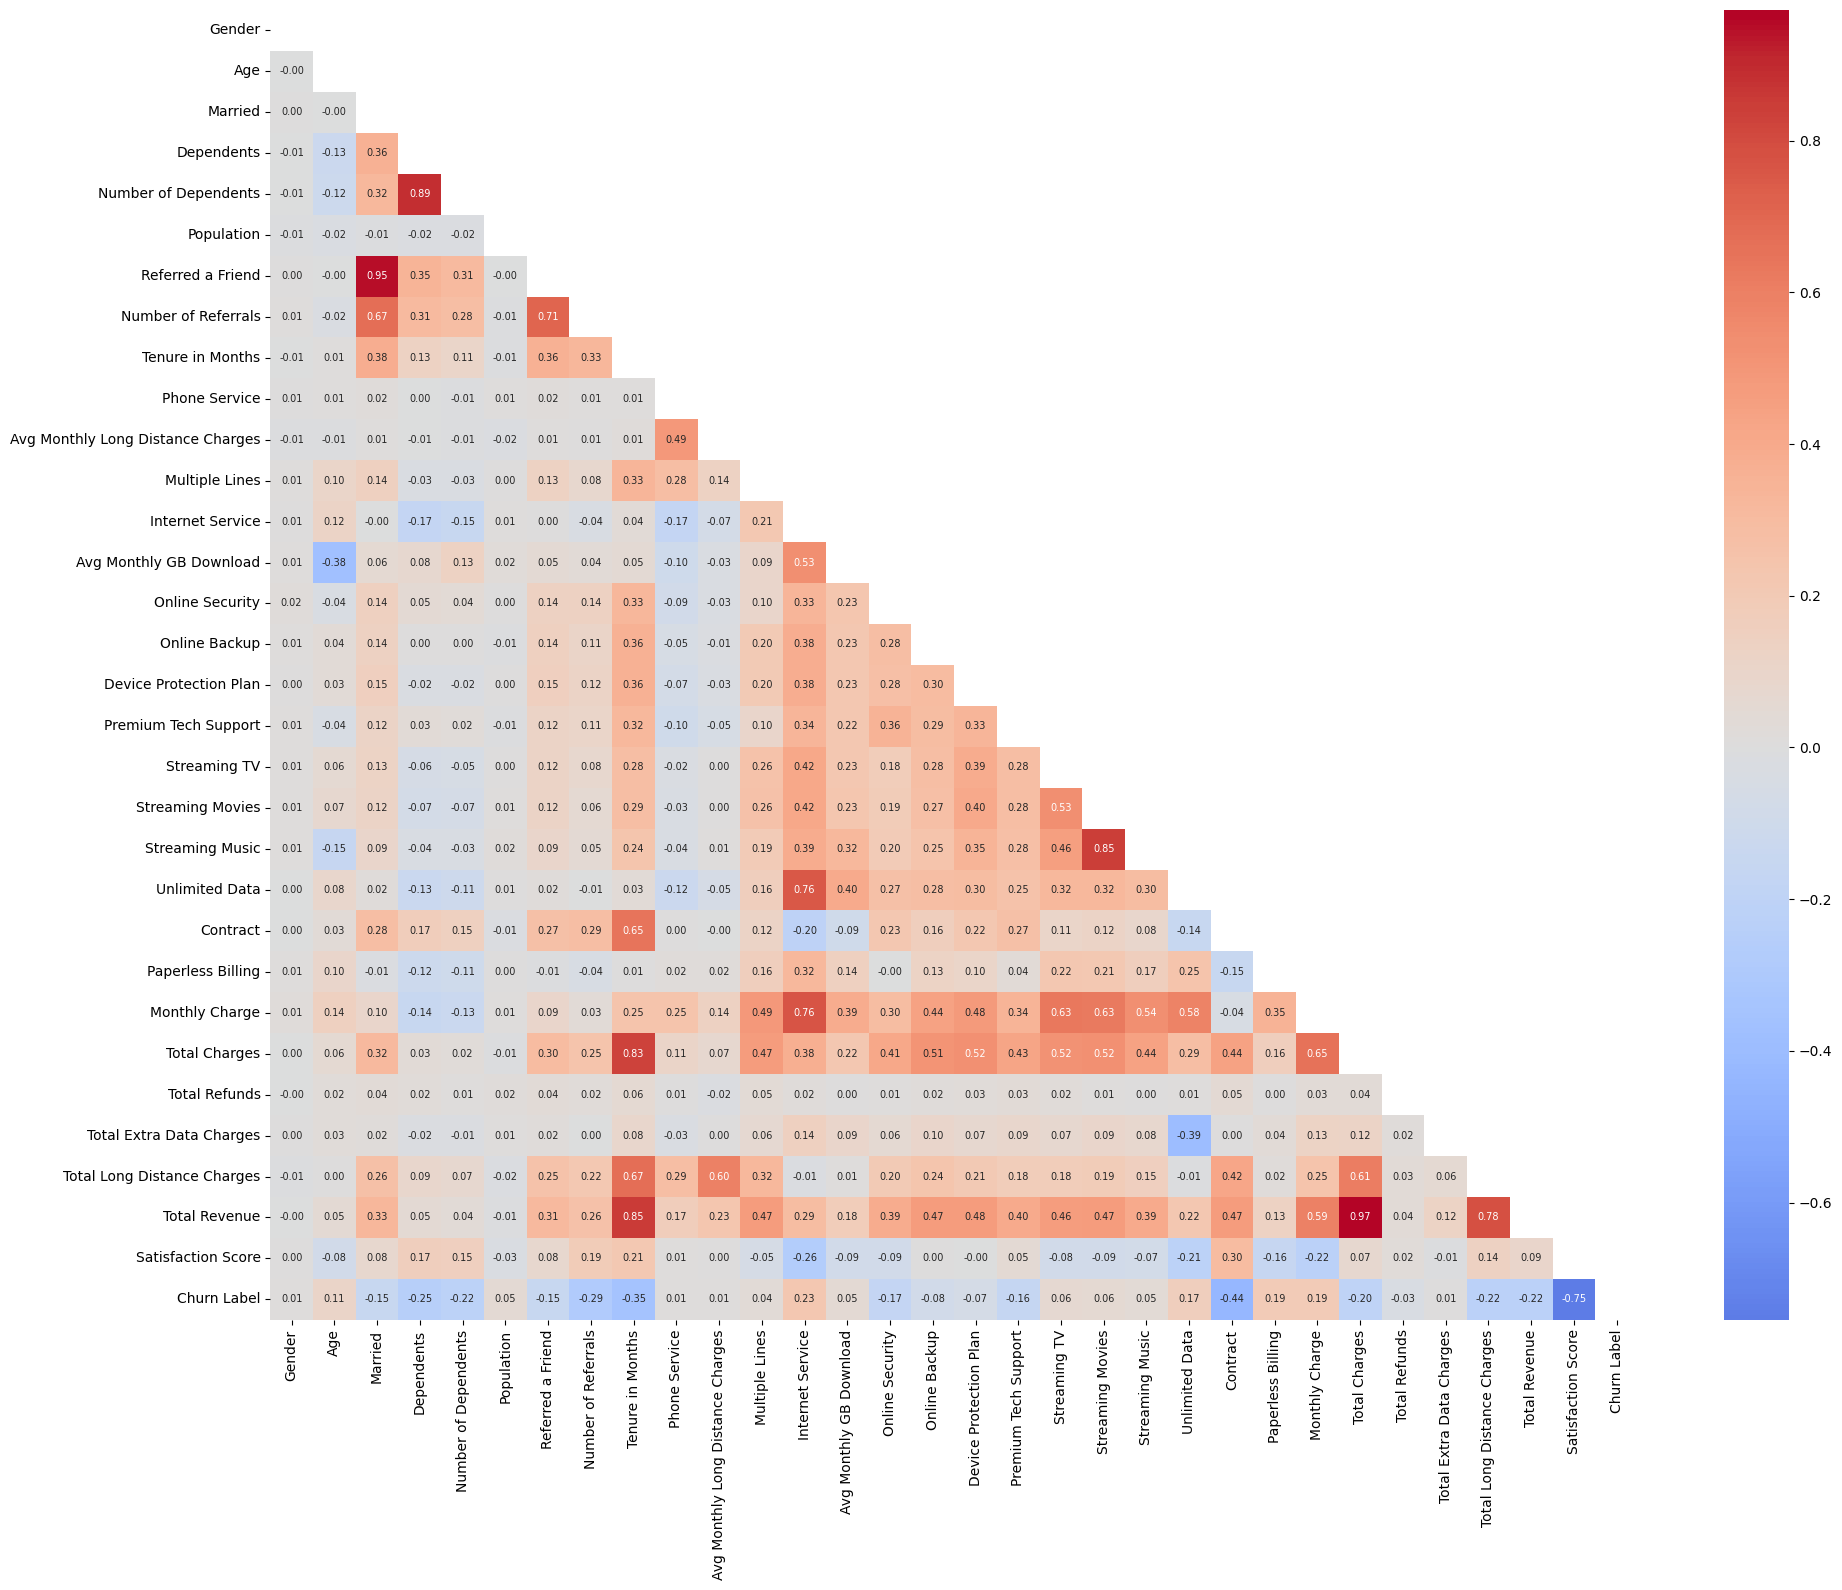

In [20]:
numeric_data = data.select_dtypes(include=['int64','float64'])
corr = numeric_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (mirror of lower)

plt.subplots(figsize=(20, 16))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, annot_kws={'size': 7})
plt.tight_layout()
plt.show()

---

- To make sure that there is no more nan row , we delete by this code :

In [15]:
data = data.dropna(how = "all")

In [16]:
data = data.dropna(subset=['Churn Label'])

- for datas that are not binary , I used one-hot encoding

In [17]:
data = pd.get_dummies(data, columns = ['Offer','Internet Type','Payment Method'] )

In [18]:
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [20]:
data.head()

,Gender,Age,Married,Dependents,Number of Dependents,Population,Referred a Friend,Number of Referrals,Tenure in Months,Phone Service,...,Offer_Offer C,Offer_Offer D,Offer_Offer E,Internet Type_Cable,Internet Type_DSL,Internet Type_Fiber Optic,Internet Type_No Internet service,Payment Method_Bank Withdrawal,Payment Method_Credit Card,Payment Method_Mailed Check
0,0.0,78.0,0.0,0.0,0.0,68701.0,0.0,0.0,1.0,0.0,...,0,0,0,0,1,0,0,1,0,0
1,1.0,74.0,1.0,1.0,1.0,55668.0,1.0,1.0,8.0,1.0,...,0,0,1,0,0,1,0,0,1,0
2,0.0,71.0,0.0,1.0,3.0,47534.0,0.0,0.0,18.0,1.0,...,0,1,0,0,0,1,0,1,0,0
3,1.0,78.0,1.0,1.0,1.0,27778.0,1.0,1.0,25.0,1.0,...,1,0,0,0,0,1,0,1,0,0
4,1.0,80.0,1.0,1.0,1.0,26265.0,1.0,1.0,37.0,1.0,...,1,0,0,0,0,1,0,1,0,0


---

In [21]:
Y = data["Churn Label"]

In [22]:
X = data.drop(["Churn Label"] , axis= 1)

---

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train , x_test , y_train , y_test = train_test_split(X , Y  , test_size= 0.2 , random_state= 42 , stratify= Y)

---

In [26]:
x_train.head()

,Gender,Age,Married,Dependents,Number of Dependents,Population,Referred a Friend,Number of Referrals,Tenure in Months,Phone Service,...,Offer_Offer C,Offer_Offer D,Offer_Offer E,Internet Type_Cable,Internet Type_DSL,Internet Type_Fiber Optic,Internet Type_No Internet service,Payment Method_Bank Withdrawal,Payment Method_Credit Card,Payment Method_Mailed Check
3593,0.0,20.0,1.0,0.0,0.0,1957.0,1.0,1.0,47.0,1.0,...,0,0,0,0,0,0,1,1,0,0
1861,0.0,63.0,0.0,0.0,0.0,20046.0,0.0,0.0,1.0,1.0,...,0,0,1,0,0,0,1,0,1,0
1348,0.0,54.0,1.0,0.0,0.0,11213.0,1.0,1.0,49.0,1.0,...,0,0,0,0,0,1,0,1,0,0
2095,1.0,26.0,1.0,0.0,0.0,48690.0,1.0,1.0,37.0,1.0,...,0,0,0,0,0,1,0,1,0,0
5218,0.0,29.0,1.0,0.0,0.0,32857.0,1.0,4.0,72.0,1.0,...,0,0,0,0,0,1,0,1,0,0


In [51]:
y_train

4419    0.0
5401    0.0
5284    0.0
468     1.0
893     0.0
       ... 
4561    0.0
2548    0.0
886     0.0
730     0.0
2885    0.0
Name: Churn Label, Length: 5632, dtype: float64

In [54]:
y_test

5568    0.0
3230    0.0
4417    0.0
7015    0.0
5699    0.0
       ... 
5881    0.0
500     0.0
4035    0.0
3141    0.0
6898    0.0
Name: Churn Label, Length: 1408, dtype: float64

---

We use this module to get the report :

In [34]:
from sklearn.metrics import classification_report

---

### Logistic regression : 

In [27]:
from sklearn import linear_model

In [28]:
model1 = linear_model.LogisticRegression(max_iter=1000)
model1.fit(x_train, y_train)

c:\Program Files\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


---

### accuracy :

In [29]:
from sklearn.metrics import accuracy_score

In [35]:
y_pred = model1.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")
print(classification_report(y_test, y_pred))

Accuracy: 92.26%
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      1035
         1.0       0.90      0.80      0.85       373

    accuracy                           0.92      1408
   macro avg       0.91      0.88      0.90      1408
weighted avg       0.92      0.92      0.92      1408



---

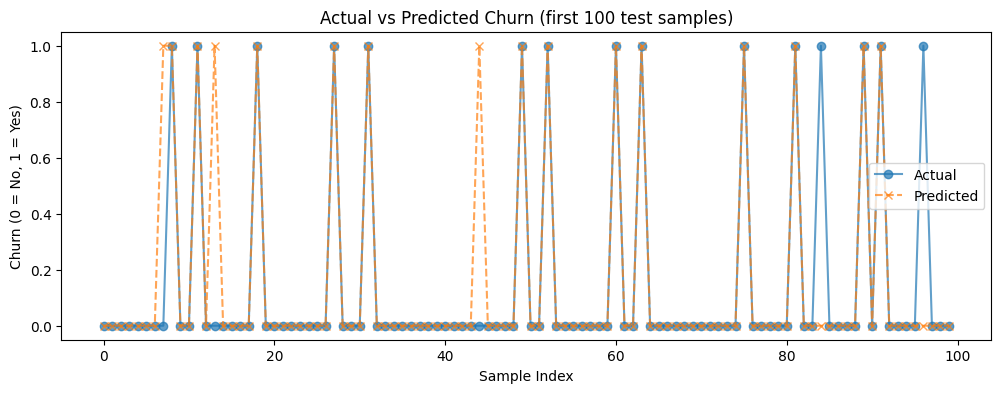

In [33]:

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Actual', marker='o', linestyle='-', alpha=0.7)
plt.plot(y_pred[:100], label='Predicted', marker='x', linestyle='--', alpha=0.7)
plt.title('Actual vs Predicted Churn (first 100 test samples)')
plt.xlabel('Sample Index')
plt.ylabel('Churn (0 = No, 1 = Yes)')
plt.legend()
plt.show()

---

## XGboost :

In [36]:
from xgboost import XGBClassifier

In [37]:
model2 = XGBClassifier()
model2.fit(x_train , y_train)
yXGB_pred = model2.predict(x_test)

In [39]:
accuracy2 = accuracy_score(y_test, yXGB_pred)
print(f"Accuracy: {accuracy2:.2%}")
print(classification_report(y_test, yXGB_pred))

Accuracy: 95.60%
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97      1035
         1.0       0.94      0.89      0.91       373

    accuracy                           0.96      1408
   macro avg       0.95      0.94      0.94      1408
weighted avg       0.96      0.96      0.96      1408



---

## SVM : 

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()
x_test = scaler.fit_transform(x_test)
x_train = scaler.transform(x_train)

In [43]:
from sklearn import svm

In [44]:
model3 = svm.SVC()
model3.fit(x_train , y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [47]:
ySVM_pred = model3.predict(x_test)

In [49]:
accuracy3 = accuracy_score(y_test, ySVM_pred)
print(f"Accuracy: {accuracy3:.2%}")
print(classification_report(y_test, ySVM_pred))


Accuracy: 96.24%
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97      1035
         1.0       0.97      0.88      0.93       373

    accuracy                           0.96      1408
   macro avg       0.97      0.94      0.95      1408
weighted avg       0.96      0.96      0.96      1408



---

## Comparison :

In [50]:
print("Logistic Regression:")
print(classification_report(y_test, y_pred))
print("XGBoost:")
print(classification_report(y_test, yXGB_pred))
print("SVM:")
print(classification_report(y_test, ySVM_pred))

Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      1035
         1.0       0.90      0.80      0.85       373

    accuracy                           0.92      1408
   macro avg       0.91      0.88      0.90      1408
weighted avg       0.92      0.92      0.92      1408

XGBoost:
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97      1035
         1.0       0.94      0.89      0.91       373

    accuracy                           0.96      1408
   macro avg       0.95      0.94      0.94      1408
weighted avg       0.96      0.96      0.96      1408

SVM:
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97      1035
         1.0       0.97      0.88      0.93       373

    accuracy                           0.96      1408
   macro avg       0.97      0.94      0.95      1408
weighted avg       0.96      0.96      

---

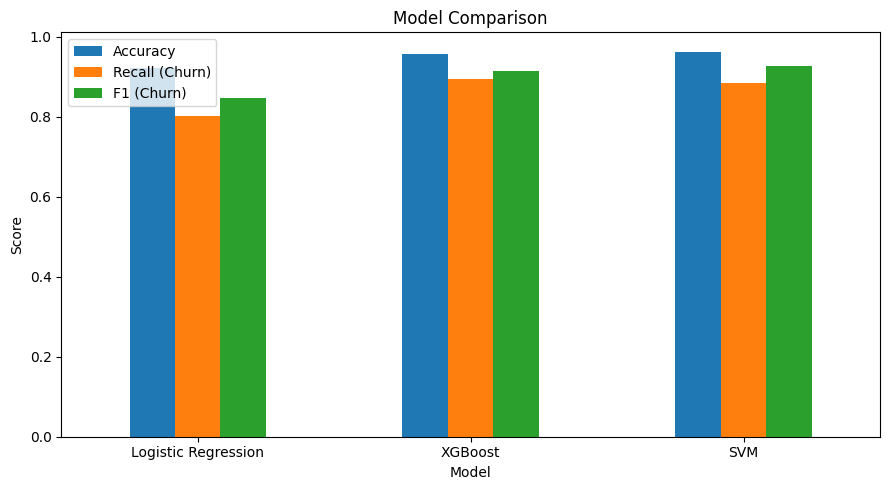

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'SVM'],
    'Accuracy': [accuracy, accuracy2, accuracy3],
    'Recall (Churn)': [
        recall_score(y_test, y_pred),
        recall_score(y_test, yXGB_pred),
        recall_score(y_test, ySVM_pred)
    ],
    'F1 (Churn)': [
        f1_score(y_test, y_pred),
        f1_score(y_test, yXGB_pred),
        f1_score(y_test, ySVM_pred)
    ]
})

results.set_index('Model').plot(kind='bar', figsize=(9,5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()